In [1]:
# Google Colab setup for Kaggle API

from google.colab import files

!pip install -q kaggle

files.upload()

!mkdir ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [2]:
# 1. Download the full zip (it's big, but reliable)
!kaggle datasets download -d mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot

# 2. Extract ONLY the DNN-EdgeIIoT-dataset.csv file
# The -j flag flattens the directory structure so it drops right into your current folder
!unzip -j edgeiiotset-cyber-security-dataset-of-iot-iiot.zip "*DNN-EdgeIIoT-dataset.csv" "*ML-EdgeIIoT-dataset.csv" -d .

# 3. Verify it's there
!ls -lh DNN-EdgeIIoT-dataset.csv

Dataset URL: https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot
License(s): CC-BY-NC-SA-4.0
 97% 1.57G/1.63G [00:01<00:00, 538MB/s]
100% 1.63G/1.63G [00:02<00:00, 855MB/s]
Archive:  edgeiiotset-cyber-security-dataset-of-iot-iiot.zip
  inflating: ./DNN-EdgeIIoT-dataset.csv  
  inflating: ./ML-EdgeIIoT-dataset.csv  
-rw-r--r-- 1 root root 1.2G Mar 18  2022 DNN-EdgeIIoT-dataset.csv


In [3]:
import pandas as pd

import numpy as np

df_ml = pd.read_csv('ML-EdgeIIoT-dataset.csv', low_memory=False)
# df_dl = pd.read_csv('DNN-EdgeIIoT-dataset.csv', low_memory=False)

# Standard Preprocessing
Prepprocess the data in accordance to steps outlined in EdgeIIoT paper

In [5]:
import sklearn
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import re


def preprocess(df, output_path=None):
    df = df.copy()

    # Drop columns
    drop_columns = [
        "frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4", "arp.dst.proto_ipv4",
        "http.file_data", "http.request.full_uri", "icmp.transmit_timestamp",
        "http.request.uri.query", "tcp.options", "tcp.payload", "tcp.srcport",
        "tcp.dstport", "udp.port", "mqtt.msg"
    ]
    df.drop(drop_columns, axis=1, inplace=True, errors='ignore')

    # Drop NaN and duplicates
    df.dropna(axis=0, how='any', inplace=True)
    df.drop_duplicates(subset=None, keep="first", inplace=True)
    df = shuffle(df, random_state=42)

    # Encode categorical features
    def encode_text_dummy(df, name):
        dummies = pd.get_dummies(df[name])
        for x in dummies.columns:
            dummy_name = f"{name}-{x}"
            df[dummy_name] = dummies[x]
        df.drop(name, axis=1, inplace=True)

    encode_text_dummy(df, 'http.request.method')
    encode_text_dummy(df, 'http.referer')
    encode_text_dummy(df, "http.request.version")
    encode_text_dummy(df, "dns.qry.name.len")
    encode_text_dummy(df, "mqtt.conack.flags")
    encode_text_dummy(df, "mqtt.protoname")
    encode_text_dummy(df, "mqtt.topic")

    # Encode labels
    le = LabelEncoder()
    df['Attack_type'] = le.fit_transform(df['Attack_type'])

    # Create mapping dictionary
    label_map = {idx: label for idx, label in enumerate(le.classes_)}

    # Scale features
    X = df.drop('Attack_type', axis=1)
    y = df['Attack_type']

    scaler = StandardScaler() # Could use Robust Scaling?
    X_scaled = scaler.fit_transform(X)

    df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    df_scaled['Attack_type'] = y.values

    # Handle special characters in column names created from encoding
    df_scaled.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df_scaled.columns]

    # Save
    if output_path:
        df_scaled.to_csv(output_path, index=False)

    return df_scaled, label_map

# df_dl_preprocessed, labels_dl = preprocess(df_dl)
df_ml_preprocessed, labels_ml = preprocess(df_ml)


In [6]:
from sklearn.model_selection import train_test_split
X = df_ml_preprocessed.drop('Attack_type', axis=1)
y = df_ml_preprocessed['Attack_type']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 91317
Val size: 30439
Test size: 30440


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                            precision_score, recall_score, accuracy_score)

def evaluate_models(models, X_train, y_train, X_val, y_val, label_map):
    """
    Train and evaluate multiple models on validation set.

    Parameters:
    -----------
    models : dict
        Dictionary of model_name: model_instance
    X_train : DataFrame or array
        Training features
    y_train : Series or array
        Training labels
    X_val : DataFrame or array
        Validation features
    y_val : Series or array
        Validation labels
    label_map : dict
        Dictionary mapping label indices to names

    Returns:
    --------
    dict : Results dictionary with predictions and confusion matrices
    """
    results = {}
    target_names = [label_map[i] for i in sorted(label_map.keys())]

    for name, model in models.items():
        print(f"\n{'='*80}")
        print(f"Training {name}...")
        print('='*80)

        # Train on full training set
        model.fit(X_train, y_train)

        # Predict on val set
        y_pred = model.predict(X_val)

        # Calculate metrics
        print(f"\n{name} Validation Set Results:")
        print(f"  Accuracy:         {accuracy_score(y_val, y_pred):.4f}")
        print(f"  Precision Macro:  {precision_score(y_val, y_pred, average='macro'):.4f}")
        print(f"  Precision Weight: {precision_score(y_val, y_pred, average='weighted'):.4f}")
        print(f"  Recall Macro:     {recall_score(y_val, y_pred, average='macro'):.4f}")
        print(f"  Recall Weight:    {recall_score(y_val, y_pred, average='weighted'):.4f}")
        print(f"  F1 Macro:         {f1_score(y_val, y_pred, average='macro'):.4f}")
        print(f"  F1 Weight:        {f1_score(y_val, y_pred, average='weighted'):.4f}")

        # Classification report
        print(f"\n{name} Classification Report:")
        print(classification_report(y_val, y_pred, target_names=target_names))

        # Confusion matrix
        cm = confusion_matrix(y_val, y_pred)

        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names)
        plt.title(f'{name} Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        results[name] = {
            'y_pred': y_pred,
            'confusion_matrix': cm,
            'accuracy': accuracy_score(y_val, y_pred),
            'f1_macro': f1_score(y_val, y_pred, average='macro'),
            'f1_weighted': f1_score(y_val, y_pred, average='weighted')
        }

    print("\n" + "="*80)
    print("EVALUATION COMPLETE")
    print("="*80)

    return results


# Baseline Results:
Standard preprocessing, no hyperparameter tuning, no SMOTE

Using traditional ML models shown to perform well on various kaggle competitions (XGBoost, CatBoost, RandomForest, LightGBM)

In [8]:
!pip install xgboost catboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.5 MB/s eta 0:00:00



Training XGBoost...

XGBoost Validation Set Results:
  Accuracy:         0.9464
  Precision Macro:  0.9398
  Precision Weight: 0.9471
  Recall Macro:     0.9250
  Recall Weight:    0.9464
  F1 Macro:         0.9309
  F1 Weight:        0.9462

XGBoost Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.97      0.94      0.96      1973
            DDoS_HTTP       0.90      0.94      0.92      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.89      0.67      0.77       171
                 MITM       1.00      0.99      0.99        72
               Normal       1.00      1.00      1.00      4820
             Password       0.85      0.82      0.83      1994
        Port_Scanning       0.94      1.00      0.97      1784
           Ransomware       0.9

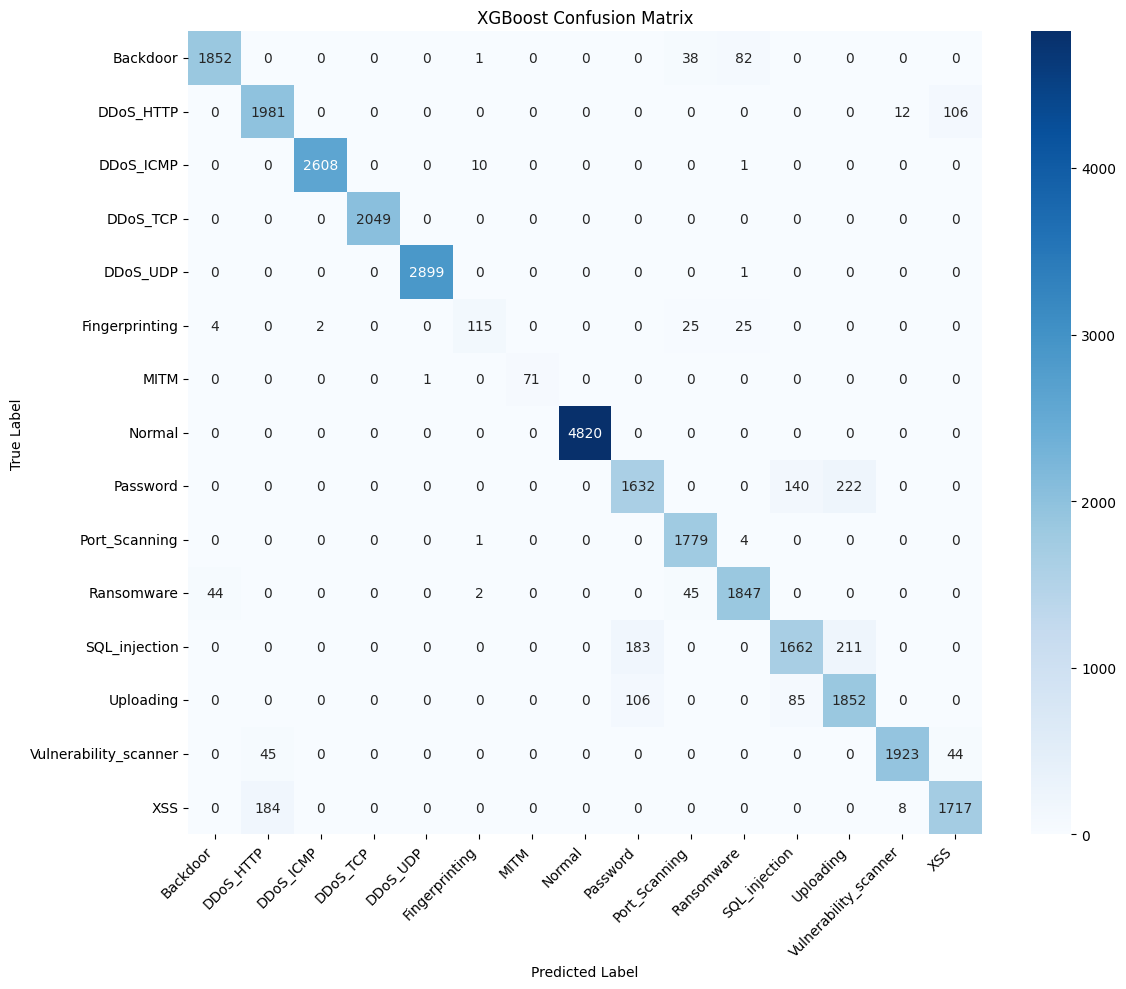


Training CatBoost...

CatBoost Validation Set Results:
  Accuracy:         0.9469
  Precision Macro:  0.9467
  Precision Weight: 0.9479
  Recall Macro:     0.9263
  Recall Weight:    0.9469
  F1 Macro:         0.9341
  F1 Weight:        0.9468

CatBoost Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.99      0.93      0.96      1973
            DDoS_HTTP       0.90      0.94      0.92      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.99      0.68      0.81       171
                 MITM       1.00      0.99      0.99        72
               Normal       1.00      1.00      1.00      4820
             Password       0.84      0.82      0.83      1994
        Port_Scanning       0.94      1.00      0.97      1784
           Ransomware       

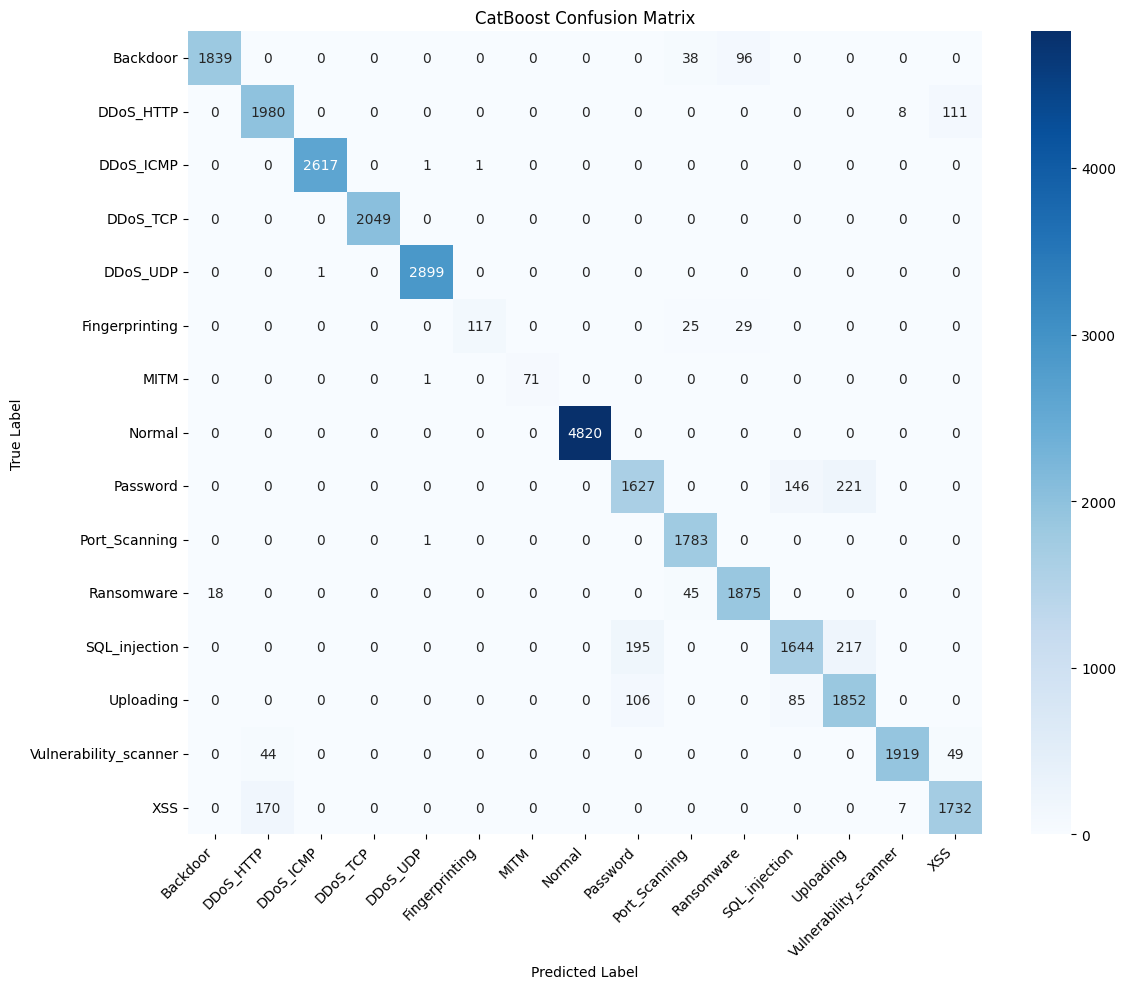


Training LightGBM...

LightGBM Validation Set Results:
  Accuracy:         0.9462
  Precision Macro:  0.9361
  Precision Weight: 0.9469
  Recall Macro:     0.9258
  Recall Weight:    0.9462
  F1 Macro:         0.9299
  F1 Weight:        0.9460

LightGBM Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.97      0.94      0.96      1973
            DDoS_HTTP       0.90      0.95      0.92      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.85      0.69      0.76       171
                 MITM       0.99      0.99      0.99        72
               Normal       1.00      1.00      1.00      4820
             Password       0.85      0.81      0.83      1994
        Port_Scanning       0.94      1.00      0.97      1784
           Ransomware       

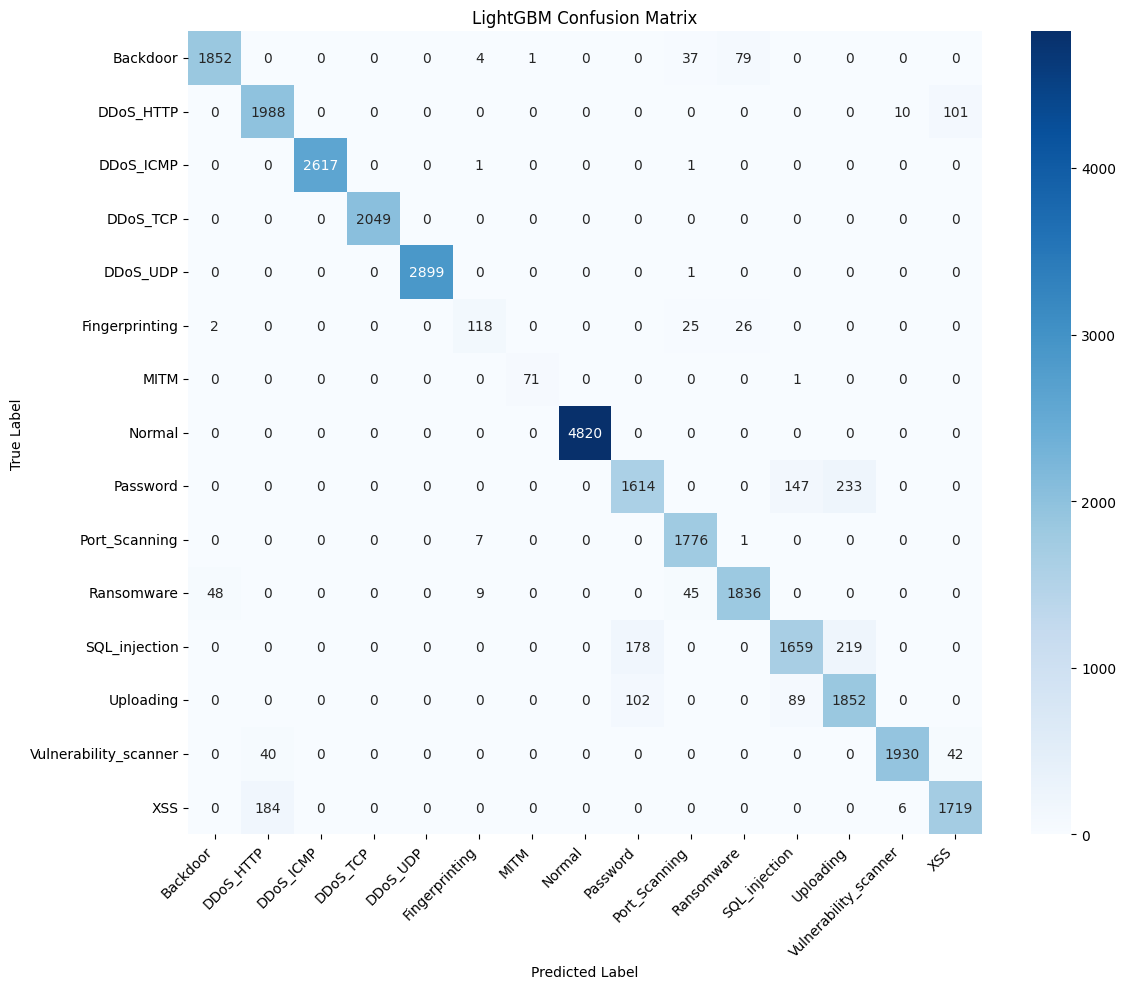


Training RandomForest...

RandomForest Validation Set Results:
  Accuracy:         0.9384
  Precision Macro:  0.9254
  Precision Weight: 0.9386
  Recall Macro:     0.9197
  Recall Weight:    0.9384
  F1 Macro:         0.9223
  F1 Weight:        0.9384

RandomForest Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.96      0.94      0.95      1973
            DDoS_HTTP       0.90      0.89      0.89      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.80      0.70      0.75       171
                 MITM       1.00      1.00      1.00        72
               Normal       1.00      1.00      1.00      4820
             Password       0.81      0.83      0.82      1994
        Port_Scanning       0.94      0.99      0.97      1784
           Ranso

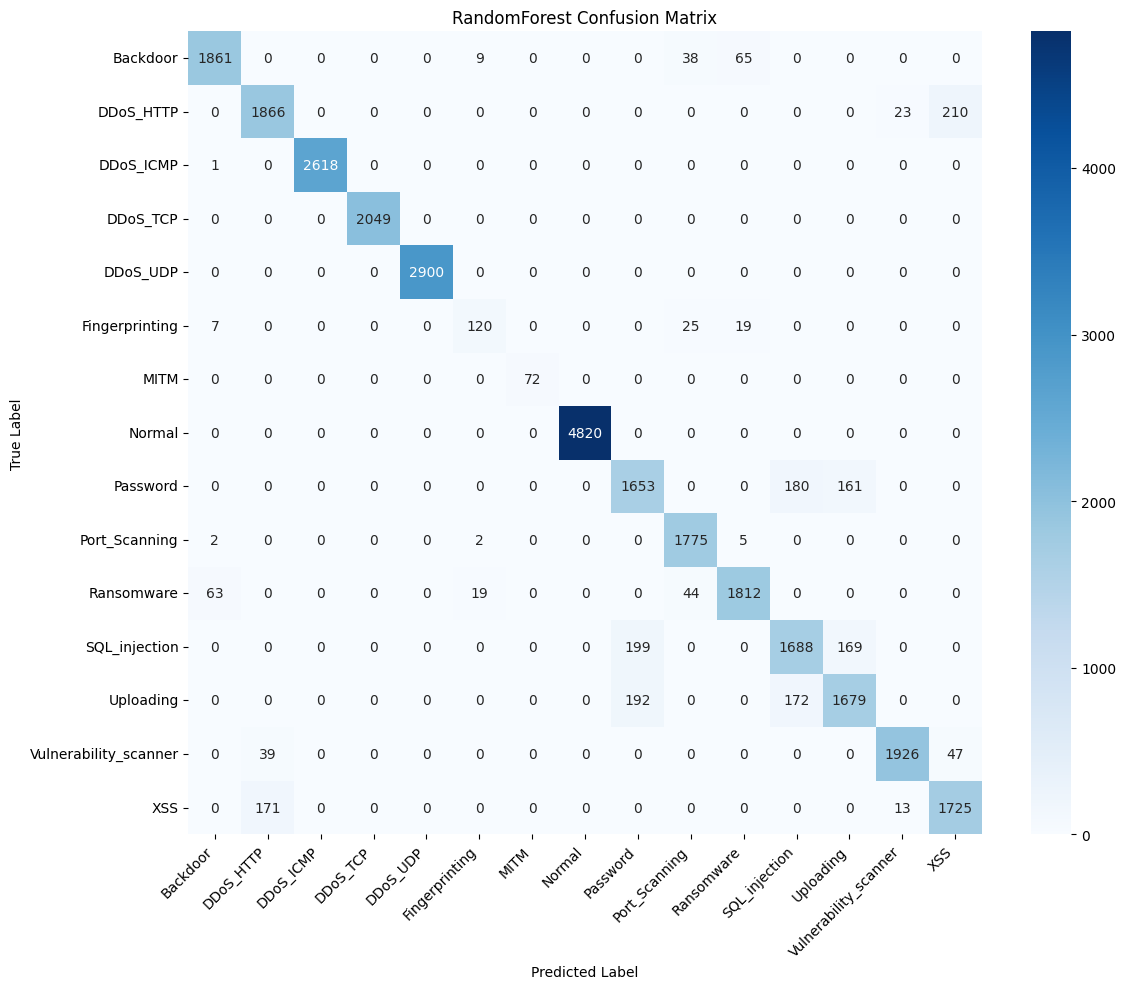


Training ExtraTrees...

ExtraTrees Validation Set Results:
  Accuracy:         0.9348
  Precision Macro:  0.9190
  Precision Weight: 0.9351
  Recall Macro:     0.9157
  Recall Weight:    0.9348
  F1 Macro:         0.9172
  F1 Weight:        0.9348

ExtraTrees Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.96      0.95      0.95      1973
            DDoS_HTTP       0.88      0.87      0.87      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.75      0.70      0.72       171
                 MITM       1.00      1.00      1.00        72
               Normal       1.00      1.00      1.00      4820
             Password       0.81      0.83      0.82      1994
        Port_Scanning       0.94      0.99      0.96      1784
           Ransomware 

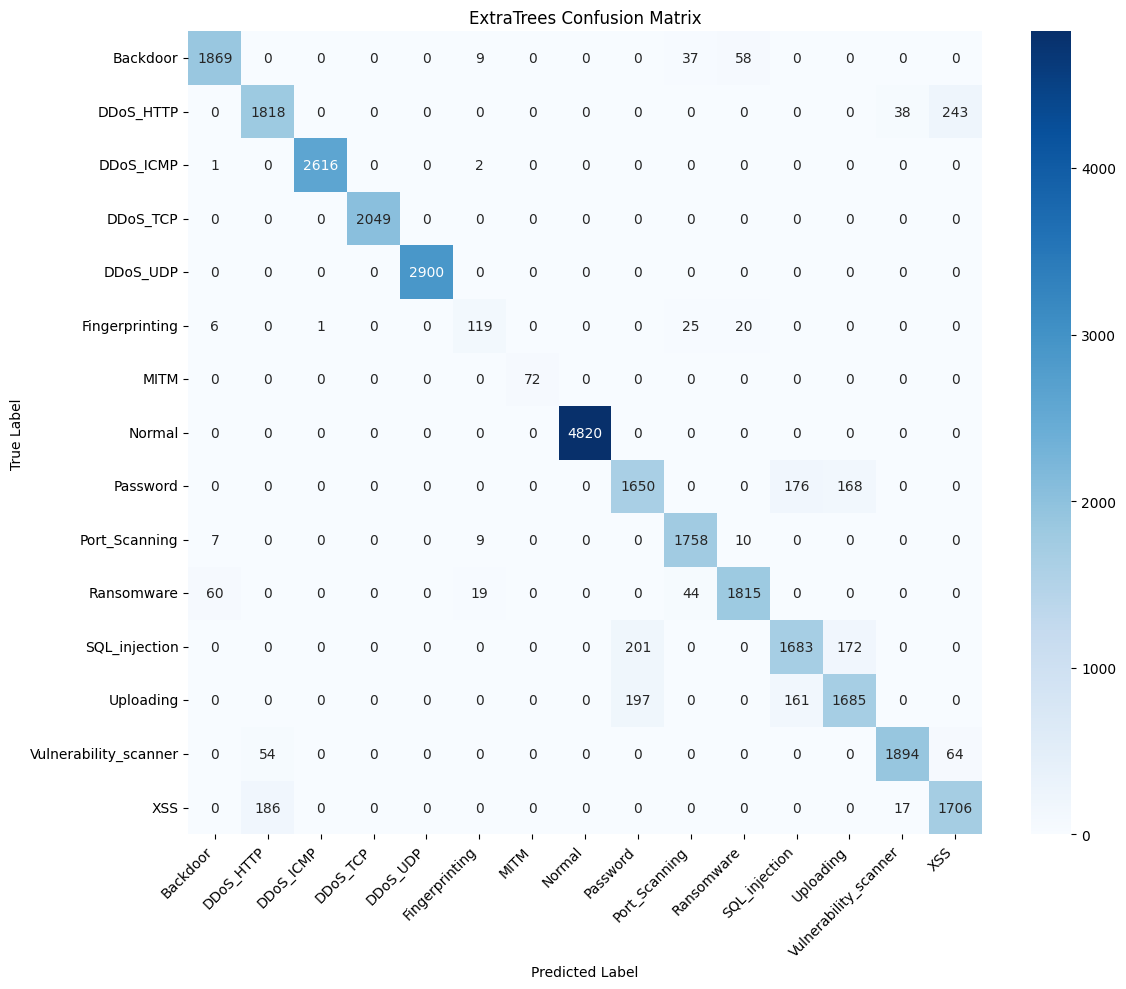


EVALUATION COMPLETE


In [9]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
import torch

models_baseline = {
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0, task_type='GPU') if torch.cuda.is_available() else CatBoostClassifier(random_state=42, verbose=0, thread_count=-1),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, n_jobs=-1)
}

results_baseline = evaluate_models(models_baseline, X_train, y_train, X_val, y_val, labels_ml)

# Ensemble Classifiers
Questions to answer:
1. Does combining our existing models in an ensemble improve performance?
2. Stacking or voting?
3. If stacking, which model performs the best as a final estimator?


Training Voting Ensemble...

Voting Ensemble Validation Set Results:
  Accuracy:         0.9829
  Precision Macro:  0.9292
  Precision Weight: 0.9829
  Recall Macro:     0.9207
  Recall Weight:    0.9829
  F1 Macro:         0.9245
  F1 Weight:        0.9829

Voting Ensemble Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.97      0.96      0.97      4805
            DDoS_HTTP       0.93      0.95      0.94      9709
            DDoS_ICMP       1.00      1.00      1.00     13588
             DDoS_TCP       1.00      1.00      1.00     10012
             DDoS_UDP       1.00      1.00      1.00     24313
       Fingerprinting       0.83      0.72      0.77       171
                 MITM       1.00      1.00      1.00        72
               Normal       1.00      1.00      1.00    272799
             Password       0.82      0.83      0.83      9987
        Port_Scanning       0.96      1.00      0.98      3995
       

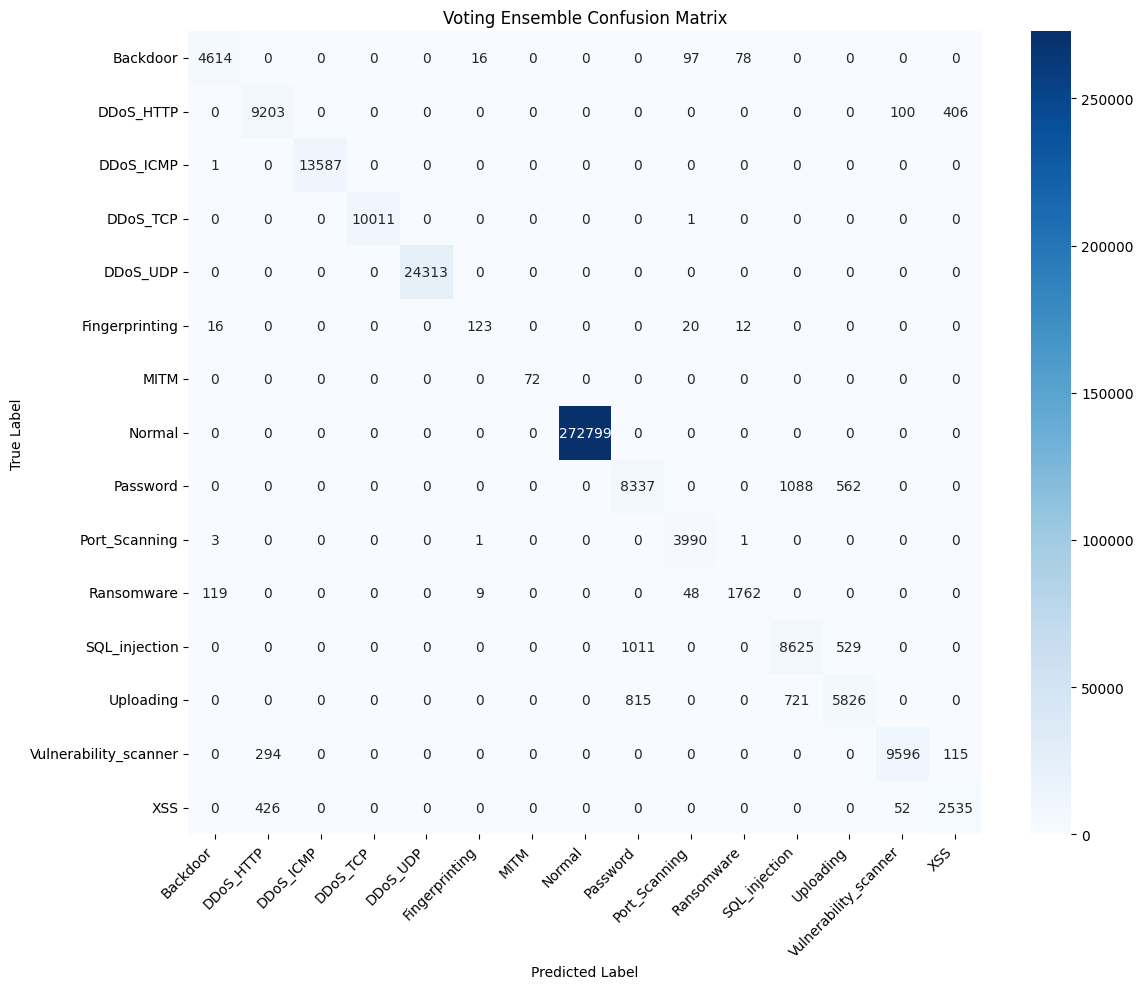


Training Stacking Ensemble...


KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier

voting_model = VotingClassifier(
    estimators=[
        ('cat', CatBoostClassifier(random_state=42, verbose=0, task_type='GPU')),
        ('rf', RandomForestClassifier(random_state=42, n_jobs=-1)),
    ],
    voting='soft'
)

stacking_model = StackingClassifier(
    estimators=[
        ('cat', CatBoostClassifier(random_state=42, verbose=0, task_type='GPU')),
        ('rf', RandomForestClassifier(random_state=42, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(multi_class='multinomial', random_state=42, n_jobs=-1)
)

models_ensemble = {
    "Voting Ensemble": voting_model,
    "Stacking Ensemble": stacking_model
}

results_ensemble = evaluate_models(models_ensemble, X_train, y_train, X_val, y_val, labels_ml)

# Results:
**CatBoost** appears as the best performing model, although hard to tell due to the fact I cannot get catboost to work in sklearn ensemble classifiers.

Across the board, it seems like the worst performing class is **Fingerprinting**, next steps likely involve adjusting preprocessing to improve performance in that class.

# Investigating Fingerprinting Predictions

`Fingerprinting` is getting misclassified as `Port_Scanning` or `Ransomware` by all models.

Plotting UMAP of all classes to see if this is an issue with seperability

### UMAP Clusters

In [ ]:
!pip install umap-learn

/opt/anaconda3/envs/cyber_env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/cyber_env/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/var/folders/w0/phbd_c51633d1cf8bvb7606r0000gn/T/ipykernel_31101/332294322.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(classes))


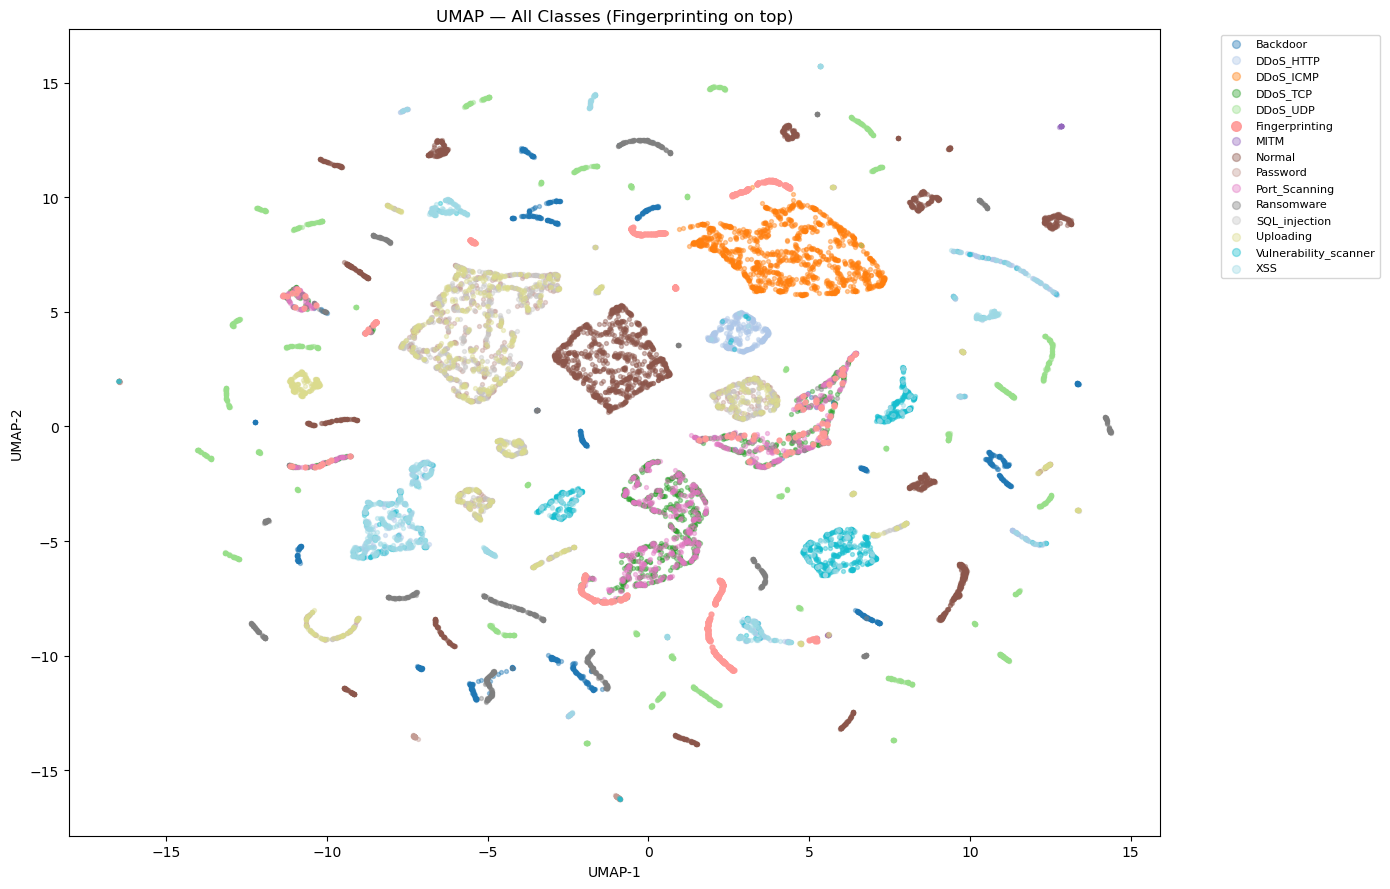

In [ ]:
# @title
import umap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y_train_decoded = y_train.map({int(k): v for k, v in labels_ml.items()})

target_class = 'Fingerprinting'

fp_mask = y_train_decoded == target_class
X_fp = X_train[fp_mask]
y_fp = y_train_decoded[fp_mask]

n_other = min(15000, (~fp_mask).sum())
X_other = X_train[~fp_mask].sample(n=n_other, random_state=42)
y_other = y_train_decoded[~fp_mask].sample(n=n_other, random_state=42)

X_sample = pd.concat([X_fp, X_other])
y_sample = pd.concat([y_fp, y_other])

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_sample)

X_vis, y_vis = X_umap, y_sample.values

# Assign a distinct color to each class
classes = np.unique(y_vis)
cmap = plt.cm.get_cmap('tab20', len(classes))
color_map = {cls: cmap(i) for i, cls in enumerate(classes)}

fig, ax = plt.subplots(figsize=(14, 9))

# Plot all classes including Fingerprinting with consistent styling
for cls in classes:
    mask = y_vis == cls
    zorder = 5 if cls == target_class else 1
    size = 12 if cls == target_class else 8
    alpha = 0.9 if cls == target_class else 0.4
    ax.scatter(
        X_vis[mask, 0], X_vis[mask, 1],
        color=color_map[cls], alpha=alpha, s=size,
        label=cls, zorder=zorder
    )

ax.set_title('UMAP — All Classes (Fingerprinting on top)')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

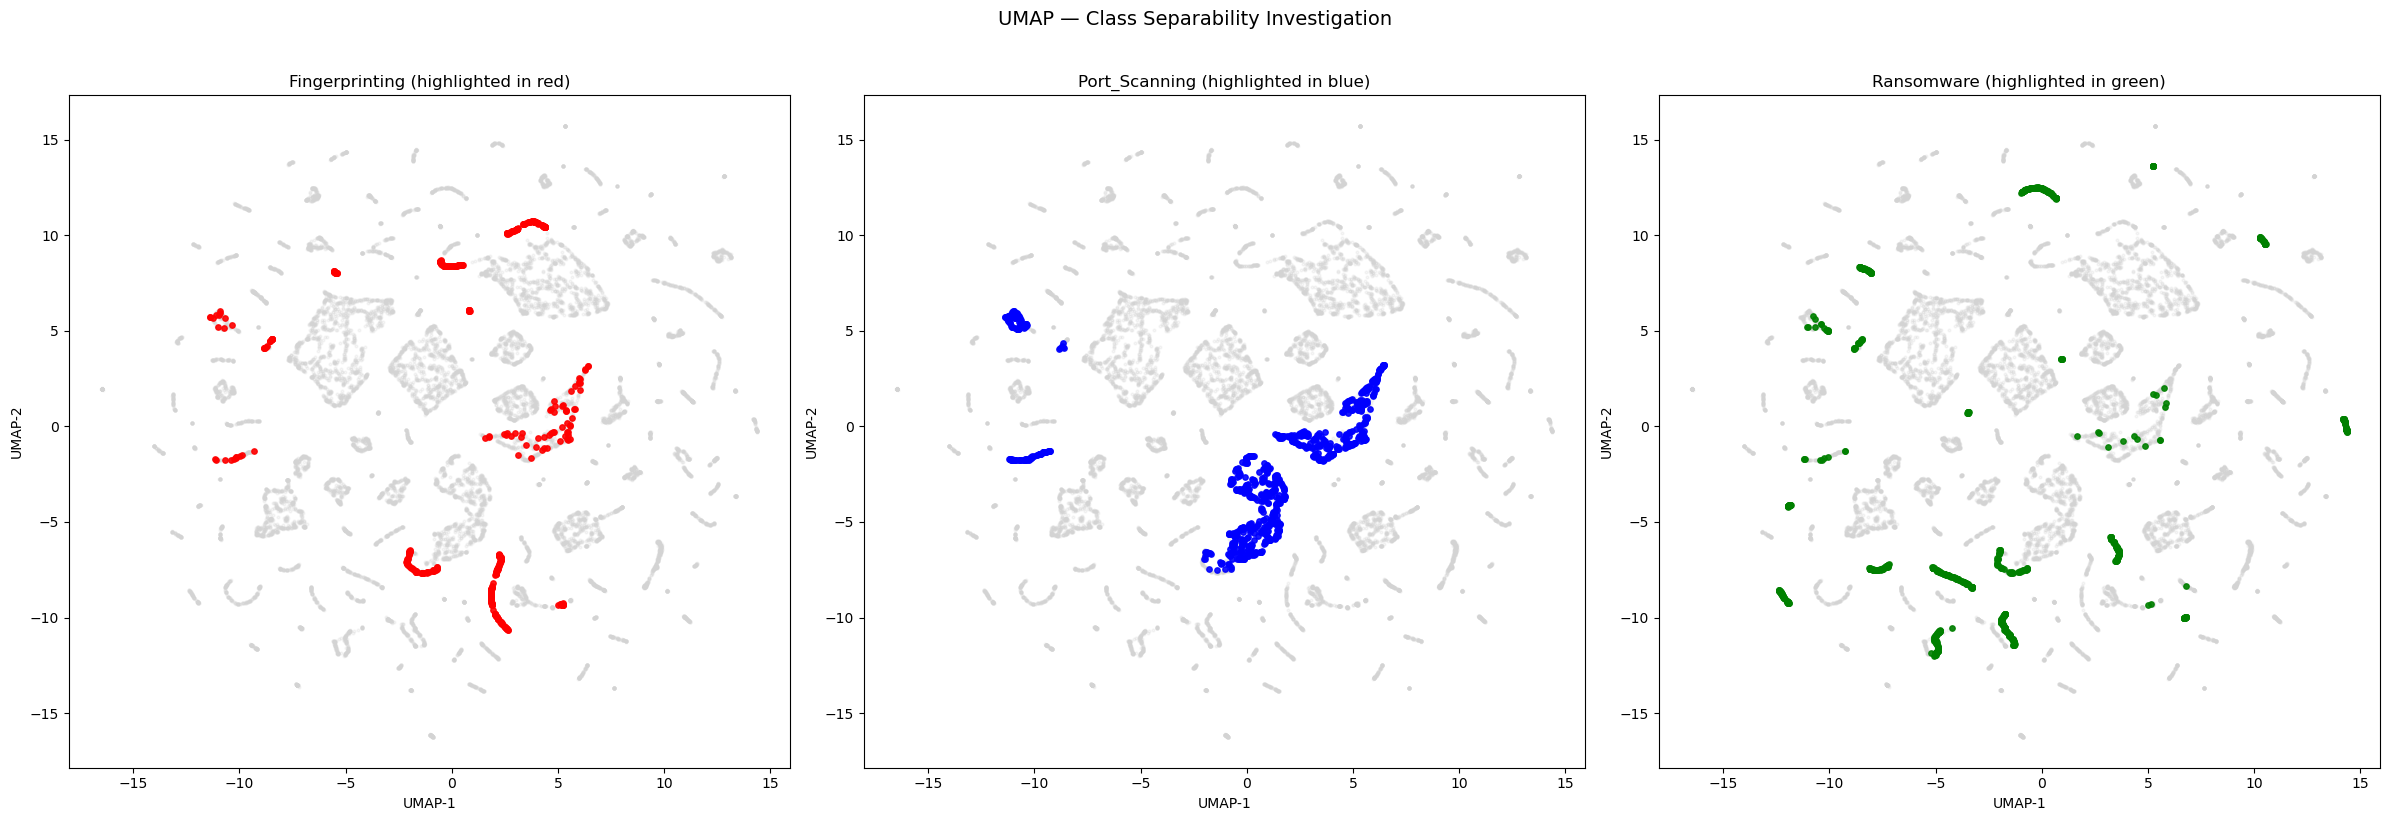

In [ ]:
# @title
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

hardcoded_colors = {
    'Fingerprinting': 'red',
    'Port_Scanning': 'blue',
    'Ransomware': 'green'
}

for ax, (focus_class, focus_color) in zip(axes, hardcoded_colors.items()):
    for cls in classes:
        mask = y_vis == cls
        is_focus = cls == focus_class
        ax.scatter(
            X_vis[mask, 0], X_vis[mask, 1],
            color=focus_color if is_focus else 'lightgrey',
            alpha=0.9 if is_focus else 0.2,
            s=15 if is_focus else 4,
            label=cls if is_focus else None,
            zorder=5 if is_focus else 1
        )
    ax.set_title(f'{focus_class} (highlighted in {focus_color})')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')

plt.suptitle('UMAP — Class Separability Investigation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### UMAP Findings
From the above plots, it's clear why `Fingerprinting` is getting misclassified, as the large majority of the `Fingerprinting` UMAP clusters overlap with `Port_Scanning` and `Ransomware`

Fixing this will likely require feature engineering

### Feature Importance

As `Catboost` performed the best on `Fingerprinting`, will use `Catboost` model to investigate which features prominently denote `Fingerprinting` vs. the other classes it overlaps with.

In [ ]:
# Which features does the best performing model on Fingerprinting care the most about?
from catboost import CatBoostClassifier
cat = CatBoostClassifier(random_state=42, verbose=0, thread_count=-1)
cat.fit(X_train, y_train)

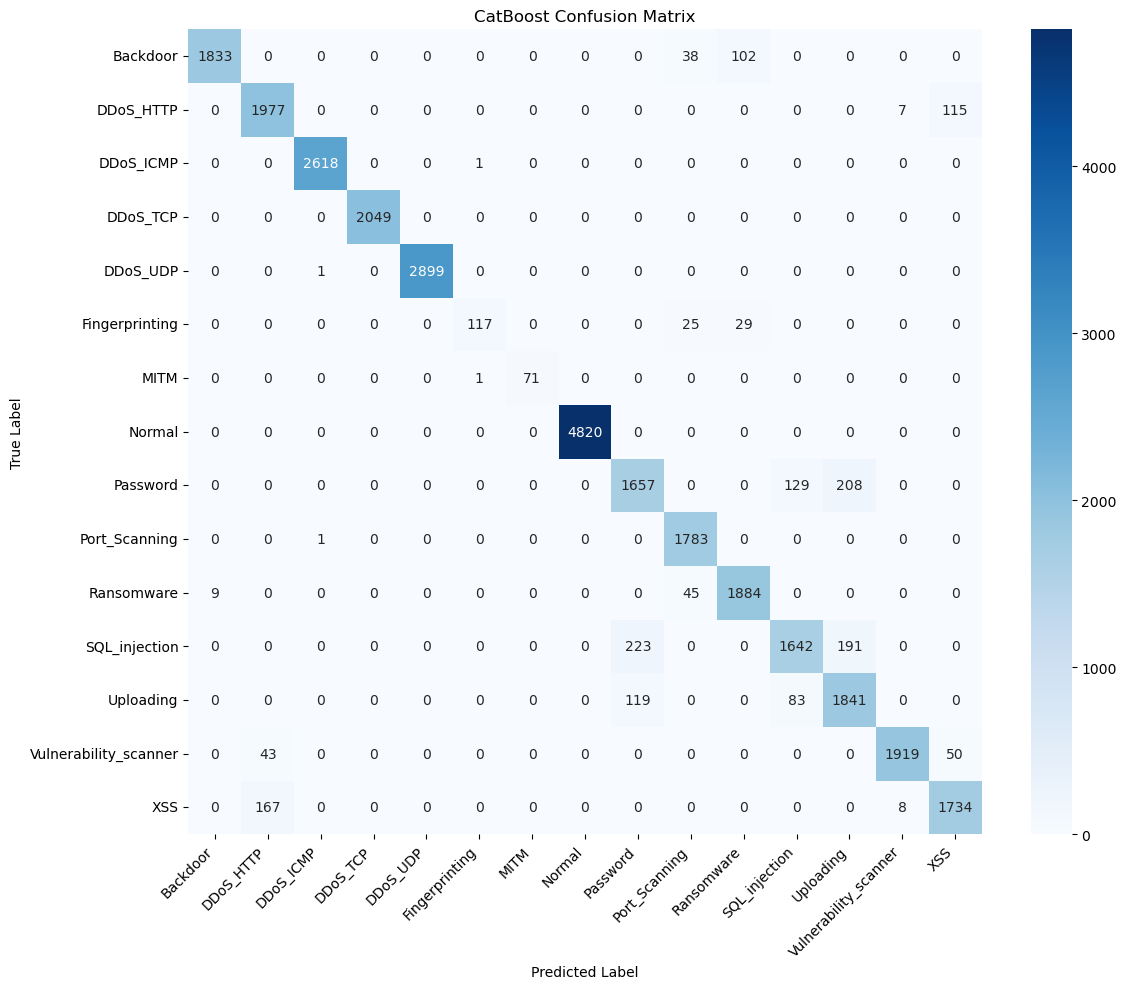

In [ ]:
# @title
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = cat.predict(X_val)

cm = confusion_matrix(y_val, y_pred)
target_names = [labels_ml[i] for i in sorted(labels_ml.keys())]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'CatBoost Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

/opt/anaconda3/envs/cyber_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


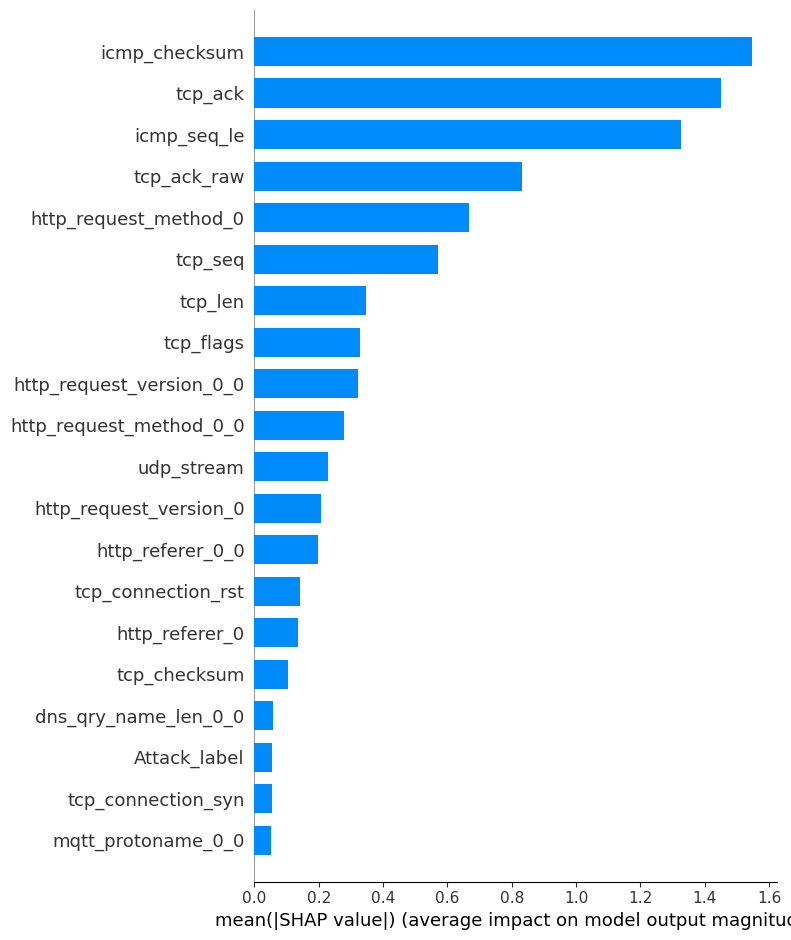

In [ ]:
# @title
import shap
explainer = shap.TreeExplainer(cat)

fingerprint_label = [key for key, value in labels_ml.items() if value == 'Fingerprinting'][0]
shap_values = explainer.shap_values(X_val[y_val == fingerprint_label])

# Handle CatBoost's 3D shap output (n_samples, n_features, n_classes)
if hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
    sv = shap_values[:, :, fingerprint_label]
else:
    sv = shap_values[fingerprint_label]

shap.summary_plot(sv,
                  X_val[y_val == fingerprint_label],
                  feature_names=X_train.columns,
                  plot_type="bar")

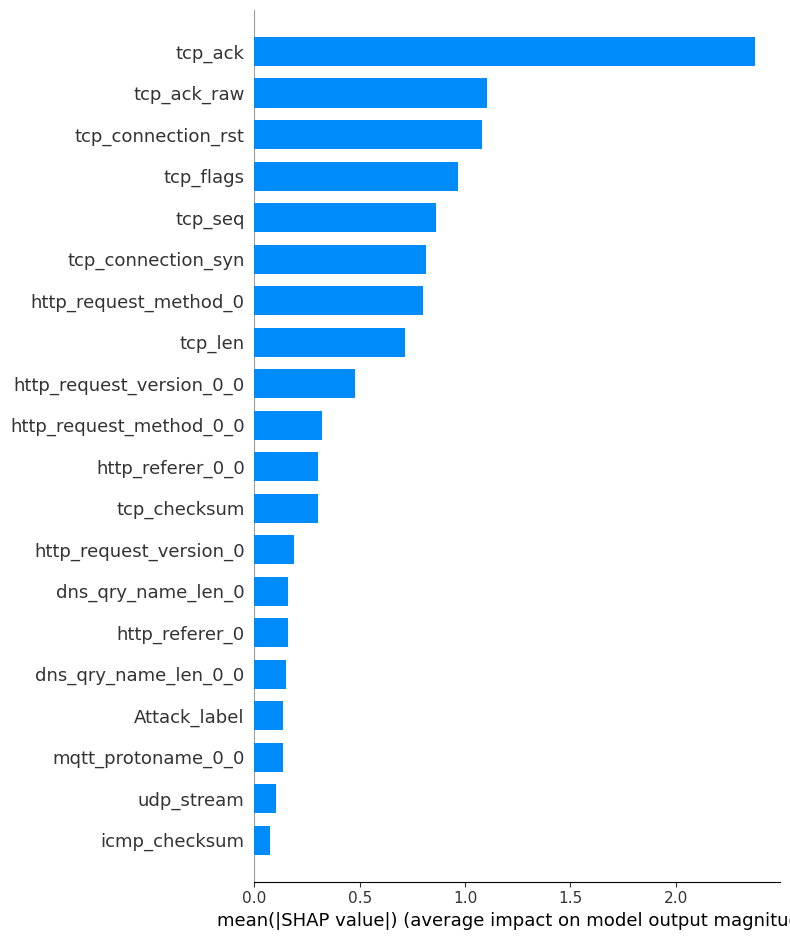

In [ ]:
port_scanning_label = [key for key, value in labels_ml.items() if value == 'Port_Scanning'][0]
shap_values = explainer.shap_values(X_val[y_val == port_scanning_label])

# Handle CatBoost's 3D shap output (n_samples, n_features, n_classes)
if hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
    sv = shap_values[:, :, port_scanning_label]
else:
    sv = shap_values[port_scanning_label]

shap.summary_plot(sv,
                  X_val[y_val == port_scanning_label],
                  feature_names=X_train.columns,
                  plot_type="bar")

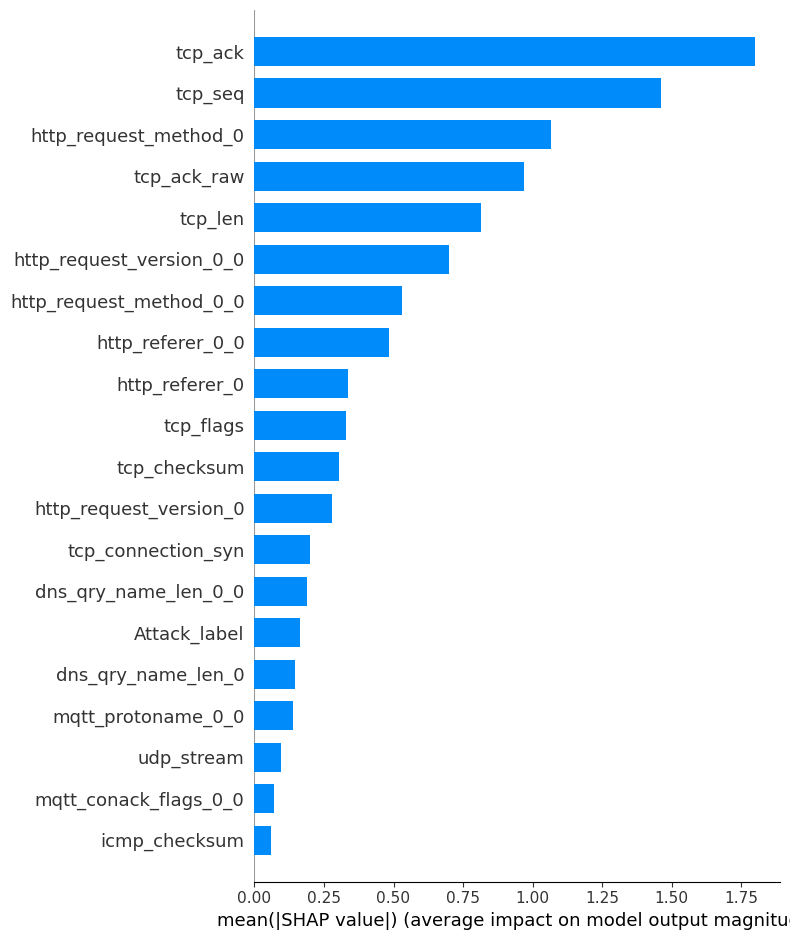

In [ ]:
ransomware_label = [key for key, value in labels_ml.items() if value == 'Ransomware'][0]
shap_values = explainer.shap_values(X_val[y_val == ransomware_label])

# Handle CatBoost's 3D shap output (n_samples, n_features, n_classes)
if hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
    sv = shap_values[:, :, ransomware_label]
else:
    sv = shap_values[ransomware_label]

shap.summary_plot(sv,
                  X_val[y_val == ransomware_label],
                  feature_names=X_train.columns,
                  plot_type="bar")

### SHAP Plot Findings:
All classes seem to have `tcp_ack` and `tcp_ack_raw` as highly significant features, likely contributing to the overlap

For `Fingerprinting`, most signfificant features are `icmp_checksum` and `icmp_seq_le`.


**Ideas:**
- Create interaction features between `icmp_checksum` and `icmp_seq_le`
- Shared TCP features are likely causing the overap, engineer `Fingerprinting`-specific feature capturing combination of ICMP and TCP patterns

# Feature Selection and Engineering

In [10]:
!pip install imblearn

## Feature Selection

Since from the UMAP plots above, it seems like our weak class performance are due to seperability and not class imbalance, we will focus primarily on feature engineering and selection

In [15]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import ExtraTreesClassifier
from catboost import CatBoostClassifier
import numpy as np

def multi_metric_feature_selection(X_train, y_train, k=30):
    f_scores = SelectKBest(f_classif, k='all').fit(X_train, y_train).scores_
    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

    etc = CatBoostClassifier(
        task_type="GPU",
        devices="0",
        verbose=0,
        random_seed=42
    )
    etc.fit(X_train, y_train)
    et_scores = etc.get_feature_importance()

    def normalize(arr):
        return (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)

    fused = normalize(f_scores) + normalize(mi_scores) + normalize(et_scores)
    top_k_indices = np.argsort(fused)[::-1][:k]
    return top_k_indices, fused

# Drop constant columns
constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant columns: {constant_cols}")
    X_train = X_train.drop(columns=constant_cols)
    X_val   = X_val.drop(columns=constant_cols)
    X_test  = X_test.drop(columns=constant_cols)

top_features, scores = multi_metric_feature_selection(X_train, y_train, k=30)

X_train_sel = X_train.iloc[:, top_features]
X_val_sel   = X_val.iloc[:, top_features]
X_test_sel  = X_test.iloc[:, top_features]

print(f"Selected features: {X_train_sel.columns.tolist()}")

counter = Counter(y_train)
print(f"Before resampling: {dict(sorted(counter.items()))}")

model = CatBoostClassifier(
    task_type="GPU",
    devices="0",
    eval_metric="TotalF1",
    early_stopping_rounds=50,
    verbose=100,
    random_seed=42,
)

model.fit(
    X_train_sel, y_train,
    eval_set=(X_val_sel, y_val),
    use_best_model=True
)

y_pred = model.predict(X_val_sel)
print(classification_report(y_val, y_pred))
print(f1_score(y_val, y_pred, average='macro'))


Selected features: ['http_referer_0_0', 'tcp_ack', 'tcp_seq', 'http_request_method_0_0', 'tcp_ack_raw', 'tcp_flags', 'tcp_len', 'http_request_method_0', 'http_referer_0', 'mqtt_conack_flags_0_0', 'http_request_version_0', 'tcp_checksum', 'udp_stream', 'Attack_label', 'dns_qry_name_len_0_0', 'dns_qry_name_len_0', 'mqtt_protoname_0_0', 'icmp_seq_le', 'mqtt_topic_0_0', 'mqtt_topic_0', 'mqtt_protoname_0', 'mqtt_conack_flags_0', 'tcp_flags_ack', 'icmp_checksum', 'http_content_length', 'tcp_connection_rst', 'tcp_connection_syn', 'http_request_version_HTTP_1_1', 'http_request_method_GET', 'http_response']
Before resampling: {0: 5919, 1: 6297, 2: 7858, 3: 6149, 4: 8698, 5: 511, 6: 214, 7: 14461, 8: 5984, 9: 5353, 10: 5813, 11: 6169, 12: 6128, 13: 6038, 14: 5725}
Learning rate set to 0.1659
0:	learn: 0.5739616	test: 0.5717331	best: 0.5717331 (0)	total: 8.31ms	remaining: 8.3s
100:	learn: 0.9481213	test: 0.9462229	best: 0.9462229 (100)	total: 718ms	remaining: 6.39s
200:	learn: 0.9500782	test: 0.9

In [16]:
!pip install shap

In [21]:
import shap

y_pred = model.predict(X_val_sel)
report = classification_report(y_val, y_pred, output_dict=True)

weak_classes = [
    cls for cls, metrics in report.items()
    if isinstance(metrics, dict) and metrics["f1-score"] < 0.85
]
print(f"Weak classes: {weak_classes}")

# ── Step 2: SHAP — what features matter for weak classes vs everything else ──
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val_sel)  # shape: (n_samples, n_features, n_classes)

label_map = {v: k for k, v in labels_ml.items()}  # str -> int
class_names = [str(c) for c in model.classes_]

for cls in weak_classes:
    cls_name = labels_ml.get(int(cls), cls)
    cls_idx = class_names.index(str(cls))

    shap_for_class = shap_values[:, :, cls_idx]  # (n_samples, n_features)

    mean_abs_shap = np.abs(shap_for_class).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:10]
    top_features = X_val_sel.columns[top_idx].tolist()

    print(f"\n── {cls_name} top SHAP features ──")
    for f, i in zip(top_features, top_idx):
        print(f"  {f}: {mean_abs_shap[i]:.4f}")

Weak classes: ['5', '8', '11']

── Fingerprinting top SHAP features ──
  http_referer_0_0: 2.0487
  tcp_ack: 1.1079
  http_request_method_0_0: 1.0295
  tcp_ack_raw: 0.7442
  tcp_seq: 0.6638
  http_request_method_0: 0.5692
  tcp_len: 0.3711
  http_referer_0: 0.3504
  http_request_version_0: 0.2277
  icmp_checksum: 0.1732

── Password top SHAP features ──
  http_referer_0_0: 2.8996
  tcp_ack: 0.6680
  http_request_method_0: 0.6138
  http_referer_0: 0.5746
  tcp_seq: 0.5116
  http_request_method_0_0: 0.4316
  tcp_len: 0.2380
  tcp_flags: 0.1343
  tcp_connection_rst: 0.1336
  tcp_checksum: 0.1288

── SQL_injection top SHAP features ──
  http_referer_0_0: 2.8601
  tcp_seq: 0.6295
  http_request_method_0: 0.6213
  http_referer_0: 0.6046
  tcp_ack: 0.4371
  http_request_method_0_0: 0.3912
  tcp_len: 0.3202
  tcp_ack_raw: 0.1421
  tcp_connection_rst: 0.1415
  tcp_flags: 0.1405


## Engineer Features to Improve Weak Class Performance

In [25]:
def engineer_http_attack_features(X):
    X = X.copy()

    # ── TCP sequence behavior ─────────────────────────────────────────────────
    # Fingerprinting tends to have large seq jumps (scanning many endpoints)
    # Password tends to have tight sequential acks (repeated login attempts)
    if "tcp_seq" in X.columns and "tcp_ack" in X.columns:
        X["tcp_seq_ack_delta"] = np.abs(X["tcp_seq"] - X["tcp_ack"])
        X["tcp_seq_ack_ratio"] = X["tcp_seq"] / (X["tcp_ack"] + 1e-9)

    if "tcp_seq" in X.columns and "tcp_ack_raw" in X.columns:
        X["tcp_seq_ack_raw_delta"] = np.abs(X["tcp_seq"] - X["tcp_ack_raw"])

    # ── TCP payload size signals ──────────────────────────────────────────────
    # SQL_injection payloads are larger (SQL strings in body)
    # Fingerprinting payloads are small (probe requests)
    if "tcp_len" in X.columns:
        X["log_tcp_len"] = np.log1p(X["tcp_len"])
        X["tcp_len_sq"] = X["tcp_len"] ** 2  # amplify large payload signal

    if "tcp_len" in X.columns and "tcp_ack" in X.columns:
        X["payload_per_ack"] = X["tcp_len"] / (X["tcp_ack"] + 1e-9)

    # ── HTTP method entropy proxy ─────────────────────────────────────────────
    # Fingerprinting uses varied methods (GET, HEAD, OPTIONS)
    # Password/SQL tend to be POST-heavy
    if "http_request_method_0" in X.columns and "http_request_method_0_0" in X.columns:
        X["http_method_interaction"] = X["http_request_method_0"] * X["http_request_method_0_0"]
        X["http_method_delta"] = np.abs(X["http_request_method_0"] - X["http_request_method_0_0"])

    # ── Referer signal engineering ────────────────────────────────────────────
    # SQL_injection often has anomalous referer (injected strings)
    # Password attacks often have consistent referer (same login page)
    # Fingerprinting has absent/random referer
    if "http_referer_0" in X.columns and "http_referer_0_0" in X.columns:
        X["referer_interaction"] = X["http_referer_0"] * X["http_referer_0_0"]
        X["referer_delta"] = np.abs(X["http_referer_0"] - X["http_referer_0_0"])
        X["log_referer_0"] = np.log1p(X["http_referer_0"])

    # ── TCP flag behavior ─────────────────────────────────────────────────────
    # RST flags: Fingerprinting triggers more resets (hitting closed ports/paths)
    # Password: SYN-ACK heavy (persistent connections for auth)
    if "tcp_flags" in X.columns and "tcp_connection_rst" in X.columns:
        X["rst_flag_interaction"] = X["tcp_connection_rst"] * X["tcp_flags"]
        X["rst_to_flags_ratio"] = X["tcp_connection_rst"] / (X["tcp_flags"] + 1e-9)

    if "tcp_flags" in X.columns and "tcp_checksum" in X.columns:
        X["flags_checksum_ratio"] = X["tcp_flags"] / (X["tcp_checksum"] + 1e-9)

    # ── Cross-layer interactions ──────────────────────────────────────────────
    # Combine HTTP and TCP signals — these three classes differ most
    # in how their HTTP behavior correlates with TCP state
    if "http_referer_0_0" in X.columns and "tcp_len" in X.columns:
        X["referer_x_payload"] = X["http_referer_0_0"] * np.log1p(X["tcp_len"])

    if "http_referer_0_0" in X.columns and "tcp_seq" in X.columns:
        X["referer_x_seq"] = X["http_referer_0_0"] / (X["tcp_seq"] + 1e-9)

    if "http_request_method_0_0" in X.columns and "tcp_connection_rst" in X.columns:
        X["method_x_rst"] = X["http_request_method_0_0"] * X["tcp_connection_rst"]

    return X

X_train_eng = engineer_http_attack_features(X_train_sel)
X_val_eng   = engineer_http_attack_features(X_val_sel)
X_test_eng  = engineer_http_attack_features(X_test_sel)

print(f"Engineered feature set size: {X_train_eng.shape[1]}")
print(f"New features added: {[c for c in X_train_eng.columns if c not in X_train_sel.columns]}")

model_eng = CatBoostClassifier(
    task_type="GPU",
    devices="0",
    eval_metric="TotalF1",
    early_stopping_rounds=50,
    verbose=100,
    random_seed=42,
)

model_eng.fit(
    X_train_eng, y_train,
    eval_set=(X_val_eng, y_val),
    use_best_model=True
)

y_pred_eng = model_eng.predict(X_val_eng)
print(classification_report(y_val, y_pred_eng, target_names=[labels_ml.get(i, str(i)) for i in sorted(labels_ml)]))
print(f1_score(y_val, y_pred_eng, average='macro'))

Engineered feature set size: 47
New features added: ['tcp_seq_ack_delta', 'tcp_seq_ack_ratio', 'tcp_seq_ack_raw_delta', 'log_tcp_len', 'tcp_len_sq', 'payload_per_ack', 'http_method_interaction', 'http_method_delta', 'referer_interaction', 'referer_delta', 'log_referer_0', 'rst_flag_interaction', 'rst_to_flags_ratio', 'flags_checksum_ratio', 'referer_x_payload', 'referer_x_seq', 'method_x_rst']
Learning rate set to 0.1659
0:	learn: 0.5739616	test: 0.5717331	best: 0.5717331 (0)	total: 8.53ms	remaining: 8.52s
100:	learn: 0.9489332	test: 0.9470295	best: 0.9470295 (100)	total: 750ms	remaining: 6.67s
bestTest = 0.9478267492
bestIteration = 130
Shrink model to first 131 iterations.
                       precision    recall  f1-score   support

             Backdoor       1.00      0.93      0.96      1973
            DDoS_HTTP       0.91      0.94      0.92      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049


## Engineer Features to Specifically Improve Fingerprinting Separability

In [31]:
def engineer_fingerprinting_separation(X):
    X = X.copy()

    # ── ICMP presence flag — key discriminator ────────────────────────────────
    # Fingerprinting uses ICMP probes; Port_Scanning and Ransomware don't
    if "icmp_checksum" in X.columns:
        X["icmp_present"] = (X["icmp_checksum"] != 0).astype(int)
        X["log_icmp_checksum"] = np.log1p(X["icmp_checksum"])

    if "icmp_seq_le" in X.columns:
        X["icmp_seq_present"] = (X["icmp_seq_le"] != 0).astype(int)
        X["log_icmp_seq_le"] = np.log1p(X["icmp_seq_le"])

    # ── ICMP vs TCP interaction — separates mixed-protocol Fingerprinting ─────
    if "icmp_checksum" in X.columns and "tcp_ack" in X.columns:
        X["icmp_tcp_ack_ratio"] = X["icmp_checksum"] / (X["tcp_ack"] + 1e-9)
        X["icmp_present_x_tcp_ack"] = X["icmp_present"] * X["tcp_ack"]

    if "icmp_seq_le" in X.columns and "tcp_seq" in X.columns:
        X["icmp_seq_tcp_seq_ratio"] = X["icmp_seq_le"] / (X["tcp_seq"] + 1e-9)
        X["icmp_seq_x_tcp_seq"] = X["icmp_seq_le"] * X["tcp_seq"]

    # ── SYN flag — Port_Scanning is SYN-heavy, Fingerprinting is mixed ────────
    if "tcp_connection_syn" in X.columns and "tcp_connection_rst" in X.columns:
        X["syn_rst_ratio"] = X["tcp_connection_syn"] / (X["tcp_connection_rst"] + 1e-9)
        X["syn_plus_rst"] = X["tcp_connection_syn"] + X["tcp_connection_rst"]

    if "tcp_connection_syn" in X.columns and "icmp_checksum" in X.columns:
        X["syn_x_icmp"] = X["tcp_connection_syn"] * X["icmp_present"]
        # Port_Scanning: high SYN, no ICMP → this will be 0
        # Fingerprinting: mixed SYN + ICMP → this will be nonzero

    # ── Ransomware separation — HTTP present with no ICMP ─────────────────────
    if "http_request_method_0" in X.columns and "icmp_checksum" in X.columns:
        X["http_x_no_icmp"] = X["http_request_method_0"] * (1 - X["icmp_present"])
        X["http_x_icmp"] = X["http_request_method_0"] * X["icmp_present"]

    return X

# Apply on top of existing engineered features
X_train_eng2 = engineer_fingerprinting_separation(X_train_eng)
X_val_eng2   = engineer_fingerprinting_separation(X_val_eng)
X_test_eng2  = engineer_fingerprinting_separation(X_test_eng)

print(f"New features: {[c for c in X_train_eng2.columns if c not in X_train_eng.columns]}")

model_eng2 = CatBoostClassifier(
    task_type="GPU",
    devices="0",
    eval_metric="TotalF1",
    early_stopping_rounds=50,
    verbose=100,
    random_seed=42,
)

model_eng2.fit(
    X_train_eng2, y_train,
    eval_set=(X_val_eng2, y_val),
    use_best_model=True
)

y_pred_eng2 = model_eng2.predict(X_val_eng2)
print(classification_report(y_val, y_pred_eng2, target_names=[labels_ml.get(i, str(i)) for i in sorted(labels_ml)]))
print(f1_score(y_val, y_pred_eng2, average='macro'))

New features: ['icmp_present', 'log_icmp_checksum', 'icmp_seq_present', 'log_icmp_seq_le', 'icmp_tcp_ack_ratio', 'icmp_present_x_tcp_ack', 'icmp_seq_tcp_seq_ratio', 'icmp_seq_x_tcp_seq', 'syn_rst_ratio', 'syn_plus_rst', 'syn_x_icmp', 'http_x_no_icmp', 'http_x_icmp']
Learning rate set to 0.1659
0:	learn: 0.5739616	test: 0.5717331	best: 0.5717331 (0)	total: 8.41ms	remaining: 8.4s
100:	learn: 0.9490400	test: 0.9469069	best: 0.9469160 (99)	total: 807ms	remaining: 7.18s
200:	learn: 0.9511253	test: 0.9472603	best: 0.9478869 (164)	total: 1.64s	remaining: 6.51s
bestTest = 0.9478869005
bestIteration = 164
Shrink model to first 165 iterations.
                       precision    recall  f1-score   support

             Backdoor       1.00      0.93      0.96      1973
            DDoS_HTTP       0.90      0.95      0.93      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00

In [39]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 14.5 MB/s eta 0:00:00


## Final Preprocessing and Feature Engineering

In [70]:
import sklearn
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, LabelEncoder
import re
import numpy as np

def engineer_features(df):
    """All feature engineering on raw/unscaled data before StandardScaler."""

    # HTTP attack features
    if "tcp.seq" in df.columns and "tcp.ack" in df.columns:
        df["tcp_seq_ack_delta"] = np.abs(df["tcp.seq"] - df["tcp.ack"])
        df["tcp_seq_ack_ratio"] = df["tcp.seq"] / (df["tcp.ack"] + 1e-9)

    if "tcp.seq" in df.columns and "tcp.ack_raw" in df.columns:
        df["tcp_seq_ack_raw_delta"] = np.abs(df["tcp.seq"] - df["tcp.ack_raw"])

    if "tcp.len" in df.columns:
        df["log_tcp_len"] = np.log1p(df["tcp.len"])
        df["tcp_len_sq"] = df["tcp.len"] ** 2

    if "tcp.len" in df.columns and "tcp.ack" in df.columns:
        df["payload_per_ack"] = df["tcp.len"] / (df["tcp.ack"] + 1e-9)

    if "tcp.flags" in df.columns and "tcp.connection.rst" in df.columns:
        df["rst_flag_interaction"] = df["tcp.connection.rst"] * df["tcp.flags"]
        df["rst_to_flags_ratio"] = df["tcp.connection.rst"] / (df["tcp.flags"] + 1e-9)

    if "tcp.flags" in df.columns and "tcp.checksum" in df.columns:
        df["flags_checksum_ratio"] = df["tcp.flags"] / (df["tcp.checksum"] + 1e-9)

    # Fingerprinting vs Port_Scanning/Ransomware
    if "icmp.checksum" in df.columns:
        df["icmp_present"] = (df["icmp.checksum"] != 0).astype(int)
        df["log_icmp_checksum"] = np.log1p(df["icmp.checksum"])

    if "icmp.seq_le" in df.columns:
        df["icmp_seq_present"] = (df["icmp.seq_le"] != 0).astype(int)
        df["log_icmp_seq_le"] = np.log1p(df["icmp.seq_le"])

    if "icmp.checksum" in df.columns and "tcp.ack" in df.columns:
        df["icmp_tcp_ack_ratio"] = df["icmp.checksum"] / (df["tcp.ack"] + 1e-9)
        df["icmp_present_x_tcp_ack"] = df["icmp_present"] * df["tcp.ack"]

    if "icmp.seq_le" in df.columns and "tcp.seq" in df.columns:
        df["icmp_seq_tcp_seq_ratio"] = df["icmp.seq_le"] / (df["tcp.seq"] + 1e-9)
        df["icmp_seq_x_tcp_seq"] = df["icmp.seq_le"] * df["tcp.seq"]

    if "tcp.connection.syn" in df.columns and "tcp.connection.rst" in df.columns:
        df["syn_rst_ratio"] = df["tcp.connection.syn"] / (df["tcp.connection.rst"] + 1e-9)
        df["syn_plus_rst"] = df["tcp.connection.syn"] + df["tcp.connection.rst"]

    if "tcp.connection.syn" in df.columns and "icmp_present" in df.columns:
        df["syn_x_icmp"] = df["tcp.connection.syn"] * df["icmp_present"]

    return df


def preprocess(df, output_path=None):
    df = df.copy()

    # Drop columns
    drop_columns = [
        "frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4", "arp.dst.proto_ipv4",
        "http.file_data", "http.request.full_uri", "icmp.transmit_timestamp",
        "http.request.uri.query", "tcp.options", "tcp.payload", "tcp.srcport",
        "tcp.dstport", "udp.port", "mqtt.msg"
    ]
    df.drop(drop_columns, axis=1, inplace=True, errors='ignore')

    # Drop NaN and duplicates
    df.dropna(axis=0, how='any', inplace=True)
    df.drop_duplicates(subset=None, keep="first", inplace=True)
    df = shuffle(df, random_state=42)

    # Feature engineering
    df = engineer_features(df)

    # Encode categorical features
    def encode_text_dummy(df, name):
        dummies = pd.get_dummies(df[name])
        for x in dummies.columns:
            dummy_name = f"{name}-{x}"
            df[dummy_name] = dummies[x]
        df.drop(name, axis=1, inplace=True)

    encode_text_dummy(df, 'http.request.method')
    encode_text_dummy(df, 'http.referer')
    encode_text_dummy(df, "http.request.version")
    encode_text_dummy(df, "dns.qry.name.len")
    encode_text_dummy(df, "mqtt.conack.flags")
    encode_text_dummy(df, "mqtt.protoname")
    encode_text_dummy(df, "mqtt.topic")

    # HTTP cross-layer interations
    # These need the encoded http columns to exist first
    method_col   = next((c for c in df.columns if "http.request.method-0"   == c), None)
    method_col2  = next((c for c in df.columns if "http.request.method-0_0" == c), None)
    referer_col  = next((c for c in df.columns if "http.referer-0"          == c), None)
    referer_col2 = next((c for c in df.columns if "http.referer-0_0"        == c), None)

    if method_col and method_col2:
        df["http_method_interaction"] = df[method_col] * df[method_col2]
        df["http_method_delta"] = np.abs(df[method_col] - df[method_col2])

    if referer_col and referer_col2:
        df["referer_interaction"] = df[referer_col] * df[referer_col2]
        df["referer_delta"] = np.abs(df[referer_col] - df[referer_col2])
        df["log_referer_0"] = np.log1p(df[referer_col])

    if referer_col2 and "tcp.len" in df.columns:
        df["referer_x_payload"] = df[referer_col2] * np.log1p(df["tcp.len"])

    if referer_col2 and "tcp.seq" in df.columns:
        df["referer_x_seq"] = df[referer_col2] / (df["tcp.seq"] + 1e-9)

    if method_col2 and "tcp.connection.rst" in df.columns:
        df["method_x_rst"] = df[method_col2] * df["tcp.connection.rst"]

    if method_col and "icmp_present" in df.columns:
        df["http_x_no_icmp"] = df[method_col] * (1 - df["icmp_present"])
        df["http_x_icmp"]    = df[method_col] * df["icmp_present"]

    # Encode labels
    le = LabelEncoder()
    df['Attack_type'] = le.fit_transform(df['Attack_type'])
    label_map = {idx: label for idx, label in enumerate(le.classes_)}

    # Scale features
    X = df.drop('Attack_type', axis=1)
    y = df['Attack_type']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    df_scaled['Attack_type'] = y.values

    # Handle special characters in column names
    df_scaled.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df_scaled.columns]

    if output_path:
        df_scaled.to_csv(output_path, index=False)

    return df_scaled, label_map

df_ml = pd.read_csv('ML-EdgeIIoT-dataset.csv', low_memory=False)
df_ml_preprocessed, labels_ml = preprocess(df_ml)

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import xgboost as xgb

X = df_ml_preprocessed.drop('Attack_type', axis=1)
y = df_ml_preprocessed['Attack_type']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)



## Hyperparam Tuning
Due to the size of this dataset, a traditional grid search is unfeasible so we will be using `optuna` instead.

In [72]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import f1_score

def objective(trial):
    params = {
        "iterations": 3000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 15, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "random_strength": trial.suggest_float("random_strength", 0.1, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 64, 255),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 30),
        "task_type": "GPU",
        "devices": "0",
        "eval_metric": "TotalF1",
        "early_stopping_rounds": 100,
        "verbose": 0,
        "random_seed": 42,
    }

    model = CatBoostClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred, average="macro")


sampler = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)

study.enqueue_trial({
    "learning_rate": 0.1659,
    "depth": 6,
    "l2_leaf_reg": 3.0,
    "bagging_temperature": 1.0,
    "random_strength": 1.0,
    "border_count": 254,
    "min_data_in_leaf": 1,
})

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest macro F1: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

best_params = study.best_params | {
    "iterations": 3000,
    "task_type": "GPU",
    "devices": "0",
    "eval_metric": "TotalF1",
    "early_stopping_rounds": 100,
    "verbose": 100,
    "random_seed": 42,
}

model_tuned = CatBoostClassifier(**best_params)
model_tuned.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
)

y_pred_tuned = model_tuned.predict(X_val)
print(classification_report(y_val, y_pred_tuned, target_names=[labels_ml.get(i, str(i)) for i in sorted(labels_ml)]))
print(f1_score(y_val, y_pred_tuned, average="macro"))

[I 2026-03-11 22:26:27,402] A new study created in memory with name: no-name-1d3b2206-0295-4411-84f9-51f55f9ee767


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-11 22:26:30,610] Trial 0 finished with value: 0.9360041438655762 and parameters: {'learning_rate': 0.1659, 'depth': 6, 'l2_leaf_reg': 3.0, 'bagging_temperature': 1.0, 'random_strength': 1.0, 'border_count': 254, 'min_data_in_leaf': 1}. Best is trial 0 with value: 0.9360041438655762.
[I 2026-03-11 22:26:59,045] Trial 1 finished with value: 0.9329095263134589 and parameters: {'learning_rate': 0.03574712922600244, 'depth': 10, 'l2_leaf_reg': 7.259248719561363, 'bagging_temperature': 1.1973169683940732, 'random_strength': 0.20513382630874505, 'border_count': 93, 'min_data_in_leaf': 2}. Best is trial 0 with value: 0.9360041438655762.
[I 2026-03-11 22:27:04,091] Trial 2 finished with value: 0.9369162337653286 and parameters: {'learning_rate': 0.19030368381735815, 'depth': 8, 'l2_leaf_reg': 6.803900745073704, 'bagging_temperature': 0.041168988591604894, 'random_strength': 8.706020878304859, 'border_count': 223, 'min_data_in_leaf': 7}. Best is trial 2 with value: 0.9369162337653286.

In [73]:
import xgboost as xgb

def objective_xgb(trial):
    params = {
        "n_estimators": 3000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "tree_method": "hist",
        "device": "cuda",
        "objective": "multi:softprob",
        "num_class": len(labels_ml),
        "eval_metric": "mlogloss",
        "random_state": 42,
        "early_stopping_rounds": 100,
        "verbosity": 0,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred, average="macro")


study_xgb = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))

study_xgb.enqueue_trial({
    "learning_rate": 0.1,
    "max_depth": 6,
    "min_child_weight": 1,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0001,
    "reg_lambda": 1.0,
})

study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"\nBest XGB macro F1: {study_xgb.best_value:.4f}")
print(f"Best XGB params: {study_xgb.best_params}")

best_xgb_params = study_xgb.best_params | {
    "n_estimators": 3000,
    "tree_method": "hist",
    "device": "cuda",
    "objective": "multi:softprob",
    "num_class": len(labels_ml),
    "eval_metric": "mlogloss",
    "early_stopping_rounds": 100,
    "random_state": 42,
    "verbosity": 0,
}

model_xgb = xgb.XGBClassifier(**best_xgb_params)
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

y_pred_xgb = model_xgb.predict(X_val)
print(classification_report(y_val, y_pred_xgb, target_names=[labels_ml.get(i, str(i)) for i in sorted(labels_ml)]))
print(f1_score(y_val, y_pred_xgb, average="macro"))

[I 2026-03-11 22:34:46,158] A new study created in memory with name: no-name-0ac1b2e3-e133-4bc1-b7d7-cdb5ade3b1f5


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-11 22:34:50,792] Trial 0 finished with value: 0.9371129763004029 and parameters: {'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.0001, 'reg_lambda': 1.0}. Best is trial 0 with value: 0.9371129763004029.
[I 2026-03-11 22:35:02,526] Trial 1 finished with value: 0.9365622879564328 and parameters: {'learning_rate': 0.03574712922600244, 'max_depth': 10, 'min_child_weight': 22, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 0.000602521573620386, 'reg_lambda': 0.00019517224641449495}. Best is trial 0 with value: 0.9371129763004029.
[I 2026-03-11 22:35:07,139] Trial 2 finished with value: 0.9355351528298294 and parameters: {'learning_rate': 0.19030368381735815, 'max_depth': 8, 'min_child_weight': 22, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'reg_alpha': 1.452824663751602, 'reg_lambda': 0.0011526449540315614}. Best is trial 0 with value: 0.937

In [74]:
print("Cat best params: ", study.best_params)
print("XGB best params: ", study_xgb.best_params)

print()

print("Cat best iter: ", model_tuned.best_iteration_)
print("XGB best iter: ", model_xgb.best_iteration)


Cat best params:  {'learning_rate': 0.11640731277892373, 'depth': 10, 'l2_leaf_reg': 2.0942784303797906, 'bagging_temperature': 0.0848060789773164, 'random_strength': 6.1002685009863775, 'border_count': 205, 'min_data_in_leaf': 18}
XGB best params:  {'learning_rate': 0.08498774615962006, 'max_depth': 7, 'min_child_weight': 2, 'subsample': 0.9144519474034779, 'colsample_bytree': 0.7928963337438807, 'reg_alpha': 0.00018929574159812045, 'reg_lambda': 0.1878112914385954}

Cat best iter:  160
XGB best iter:  118


## Retrain Best Models on Train+Val then Evaluate on Test

Train+val size: (129366, 97)

Training Catboost...

Catboost Validation Set Results:
  Accuracy:         0.9482
  Precision Macro:  0.9461
  Precision Weight: 0.9497
  Recall Macro:     0.9273
  Recall Weight:    0.9482
  F1 Macro:         0.9341
  F1 Weight:        0.9481

Catboost Classification Report:
                       precision    recall  f1-score   support

             Backdoor       1.00      0.91      0.95      1479
            DDoS_HTTP       0.91      0.94      0.93      1575
            DDoS_ICMP       1.00      1.00      1.00      1965
             DDoS_TCP       1.00      1.00      1.00      1537
             DDoS_UDP       1.00      1.00      1.00      2175
       Fingerprinting       0.98      0.66      0.79       128
                 MITM       0.98      1.00      0.99        53
               Normal       1.00      1.00      1.00      3615
             Password       0.80      0.85      0.83      1496
        Port_Scanning       0.93      1.00      0.97      1338

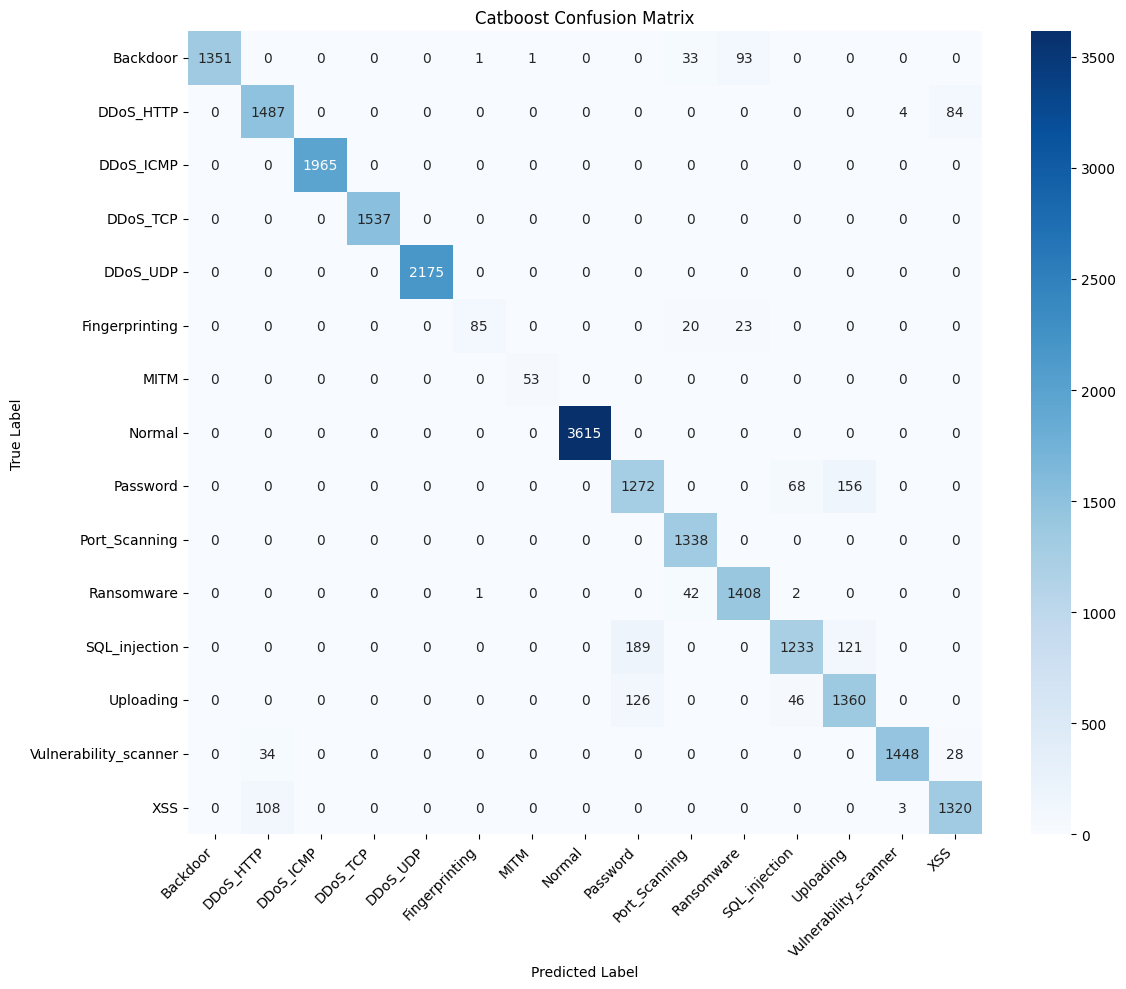


Training XGBoost...

XGBoost Validation Set Results:
  Accuracy:         0.9484
  Precision Macro:  0.9468
  Precision Weight: 0.9491
  Recall Macro:     0.9270
  Recall Weight:    0.9484
  F1 Macro:         0.9345
  F1 Weight:        0.9483

XGBoost Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.99      0.92      0.95      1479
            DDoS_HTTP       0.92      0.94      0.93      1575
            DDoS_ICMP       1.00      1.00      1.00      1965
             DDoS_TCP       1.00      1.00      1.00      1537
             DDoS_UDP       1.00      1.00      1.00      2175
       Fingerprinting       0.98      0.66      0.79       128
                 MITM       1.00      1.00      1.00        53
               Normal       1.00      1.00      1.00      3615
             Password       0.84      0.82      0.83      1496
        Port_Scanning       0.93      1.00      0.97      1338
           Ransomware       0.9

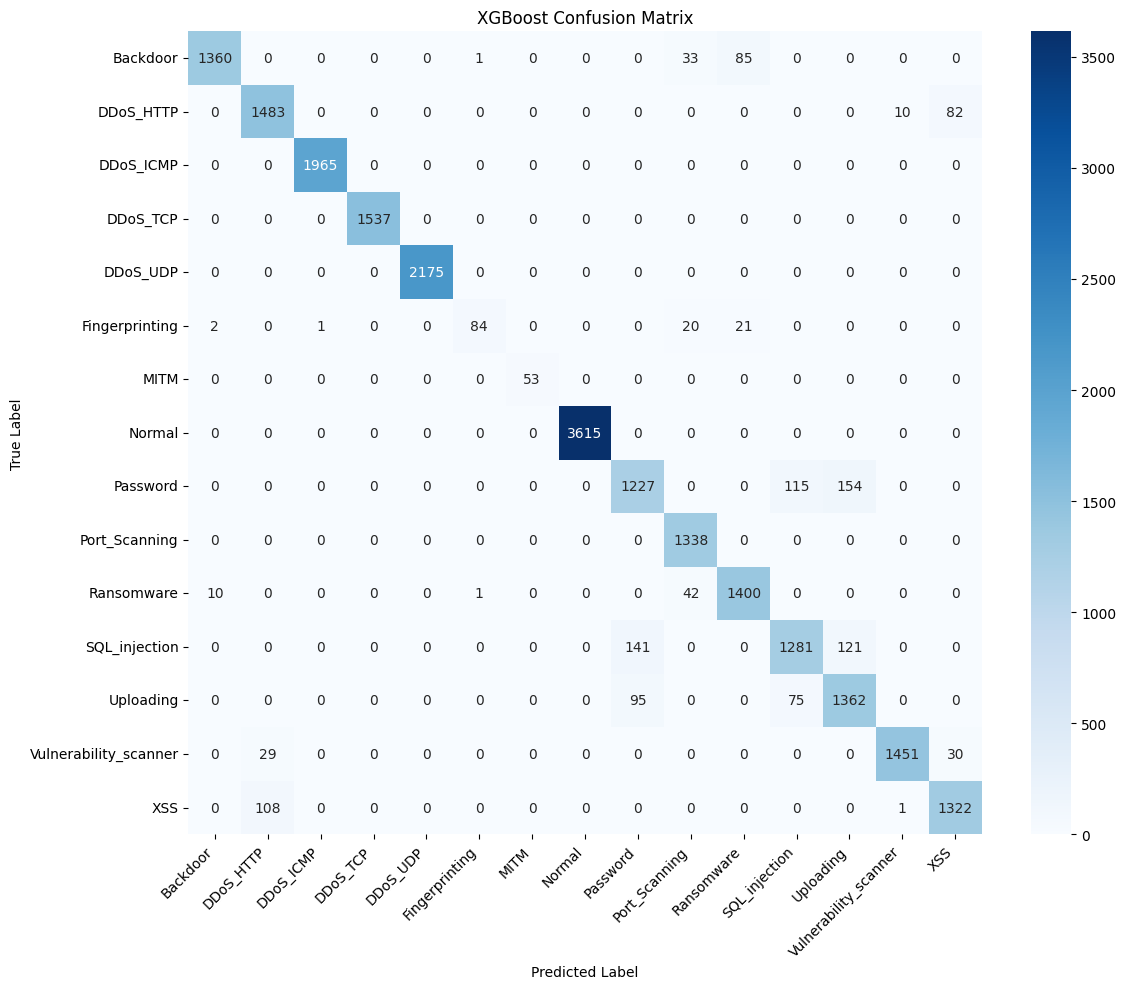


EVALUATION COMPLETE


In [83]:
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

print(f"Train+val size: {X_trainval.shape}")

model_final_cat = CatBoostClassifier(
    iterations=160,
    learning_rate=0.11640731277892373,
    depth=10,
    l2_leaf_reg=2.0942784303797906,
    bagging_temperature=0.0848060789773164,
    random_strength=6.1002685009863775,
    border_count=205,
    min_data_in_leaf=18,
    task_type="GPU",
    devices="0",
    eval_metric="TotalF1",
    verbose=0,
    random_seed=42,
)



model_final_xgb = xgb.XGBClassifier(
    n_estimators=118,
    learning_rate=0.08498774615962006,
    max_depth=7,
    min_child_weight=2,
    subsample=0.9144519474034779,
    colsample_bytree=0.7928963337438807,
    reg_alpha=0.00018929574159812045,
    reg_lambda=0.1878112914385954,
    tree_method="hist",
    device="cuda",
    objective="multi:softprob",
    num_class=len(labels_ml),
    random_state=42,
    verbosity=0,
    verbose=False,
)

models = {
    "Catboost": model_final_cat,
    "XGBoost": model_final_xgb,
}

test_results = evaluate_models(models, X_trainval, y_trainval, X_test, y_test, labels_ml)